# Quantum Preconditioning Analysis

Sections, in order: approximation ratio, PAR-based ε-hit bar charts, a combined
ε=0/ε=1% PAR line plot (presolve enabled vs disabled side by side), a
single-seed MIPSol trajectory plot, scaling across problem sizes (oracle
upper bound), a penalty-strategy comparison grid (Global fixed-ρ vs.
cross-validated ρ selection, presolve enabled vs disabled), and a
performance-distribution plot (final solution quality vs. the classical
baseline, per QAOA depth). All figures are for the QAOA (quantum)
preconditioner family only — this notebook does not analyze the
classical-sweep preconditioner, which isn't part of the accompanying paper.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "qp_gurobi").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import qp_gurobi.utils as qutils
from qp_gurobi.instance import read_dat, z_from_x
qutils = importlib.reload(qutils)

PlotConfig = qutils.PlotConfig
apply_plot_style = qutils.apply_plot_style
compute_fixed_rho_by_depth = qutils.compute_fixed_rho_by_depth
compute_hit_time_plot_limits = qutils.compute_hit_time_plot_limits
load_family_comparison_data = qutils.load_family_comparison_data
load_family_comparison_trajectory_data = qutils.load_family_comparison_trajectory_data
load_quantum_infinite_depth_comparison_data = qutils.load_quantum_infinite_depth_comparison_data
load_summary_data = qutils.load_summary_data
load_trajectory_data = qutils.load_trajectory_data
plot_hit_time_vs_penalty = qutils.plot_hit_time_vs_penalty
plot_hit_time_lines_side_by_side_presolve = qutils.plot_hit_time_lines_side_by_side_presolve
plot_mipsol_ratio_minus_one = qutils.plot_mipsol_ratio_minus_one
plot_layer_comparison_grid_by_presolve = qutils.plot_layer_comparison_grid_by_presolve
plot_layer_comparison_side_by_side_presolve = qutils.plot_layer_comparison_side_by_side_presolve
plot_ratio_minus_one = qutils.plot_ratio_minus_one
prepare_hit_time_metrics = qutils.prepare_hit_time_metrics
prepare_penalty_metrics = qutils.prepare_penalty_metrics
plot_performance_distribution = qutils.plot_performance_distribution

apply_plot_style()

N = 40          # problem size for quantum single-seed analysis
PRESOLVE = True
THRESHOLDS_TO_PLOT = [0.0, 0.001, 0.01]
LINE_EPS_THRESHOLDS = [0.0, 0.01]  # combined line plot only wants eps=0 and eps=1%
PENALTY_FILTER = None
TRAJ_PENALTY_FILTER = [round(x * 0.1, 3) for x in range(0, 13)]  # trajectory plots only: rho in [0.0, 1.2]
LOG_TIME_AXIS = True
PAR_FACTOR = 1.0
# Merged full-range sweeps + penalty-restricted (1.1-2.0) cluster runs; rebuild
# with scripts/merge_penalty_results.py whenever more cluster data lands.
RESULTS_DIR = REPO_ROOT / "results" / "merged"
# Raw instances/correlation-matrix data, downloaded separately (see README's
# Data section) since it isn't tracked in git. Only needed for the p=inf
# reference curve and the alignment-analysis cell further down; change this
# if you extracted the download somewhere other than the expected path.
DATA_ROOT = REPO_ROOT / "one_equality_new" / "complete_random"
TRAJ_SEED = 20
MIPSOL_VALUE_COL = "orig_obj"  # or "running_best_orig_obj"

# Approximation threshold for the scaling plot.
# 0.01 = find a solution within 1% of the baseline optimum.
EPS_THRESHOLD = 0.01

QUANTUM_LAYER = 1
QUANTUM_LAYERS = [1, 2, 3]
INCLUDE_P_INF = True

# N=8 is intentionally excluded: at this size the preconditioned instance's
# time-to-1%-optimal is anomalously large relative to N=12 (verified via raw
# Gurobi runtime_sec, not just the trajectory-derived hit time; baseline scales
# normally at N=8 so it isn't a hardware/overhead artifact). Most likely a
# small-N symmetry/degeneracy effect, not representative of the asymptotic
# scaling trend these plots are meant to show.
QUANTUM_SCALING_SIZES_ON  = [12, 16, 20, 24, 28, 32, 36, 40]
QUANTUM_SCALING_SIZES_OFF = [12, 16, 20, 24, 28, 32, 36, 40]

QUANTUM_SCALING_SIZES  = QUANTUM_SCALING_SIZES_ON  if PRESOLVE else QUANTUM_SCALING_SIZES_OFF
QUANTUM_COMPARE_PARAMS = QUANTUM_LAYERS + ([float("inf")] if INCLUDE_P_INF else [])

quantum_cfg = PlotConfig(n=N, family="quantum", layers=QUANTUM_LAYER)
presolve_label = "presolve enabled" if PRESOLVE else "presolve disabled"

print(f"Using {presolve_label}.")
print(f"Quantum setting: p={QUANTUM_LAYER}  (N={N})")
print(f"Include p=inf in quantum scaling comparison: {INCLUDE_P_INF}")
print(f"Scaling plot threshold: {EPS_THRESHOLD * 100:g}%-optimal")
utils_path = Path(qutils.__file__).resolve().relative_to(REPO_ROOT)
print(f"Loaded utils from: {utils_path}")


%load_ext autoreload
%autoreload 2

Using presolve enabled.
Quantum setting: p=1  (N=40)
Include p=inf in quantum scaling comparison: True
Scaling plot threshold: 1%-optimal
Loaded utils from: qp_gurobi/utils.py


## Quantum Penalty Analysis

For a single fixed problem size and QAOA depth (`N`, `QUANTUM_LAYER` above),
this section sweeps across every tested penalty ρ and answers two questions:

1. **`plot_ratio_minus_one`** — how does the preconditioned solution's
   objective compare to the classical baseline optimum at each ρ? A ratio of 0
   means the preconditioned solve found the exact same optimum as plain
   Gurobi; positive values mean it landed on a worse (higher-objective)
   solution.
2. **`plot_hit_time_vs_penalty`** — how long does it take to reach a solution
   within ε of the baseline optimum, as a function of ρ? Plotted at three ε
   thresholds (`THRESHOLDS_TO_PLOT`): exact match (ε=0), within 0.1%, and
   within 1%. Bars use PAR (Penalized Average Runtime) for instances that
   never reach the threshold — see the combined line plot below for the exact
   definition.


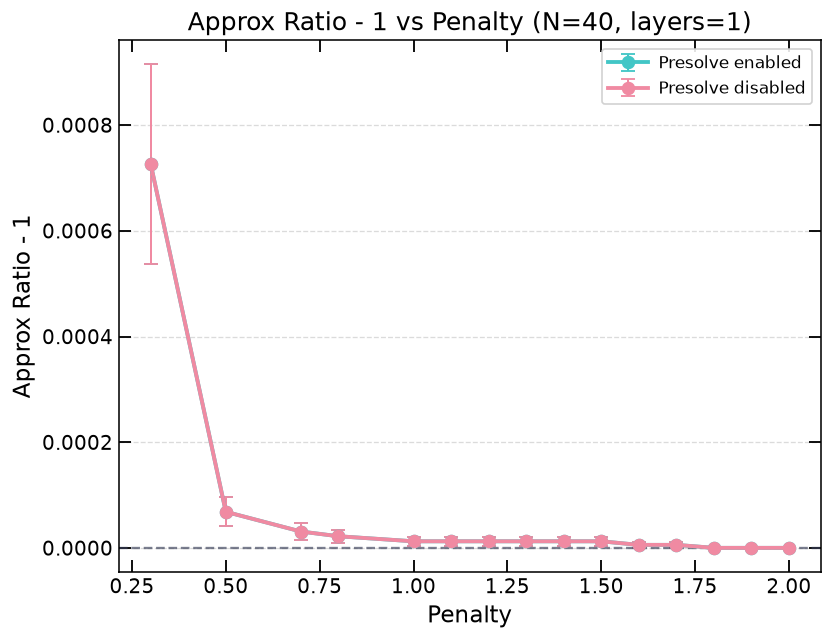

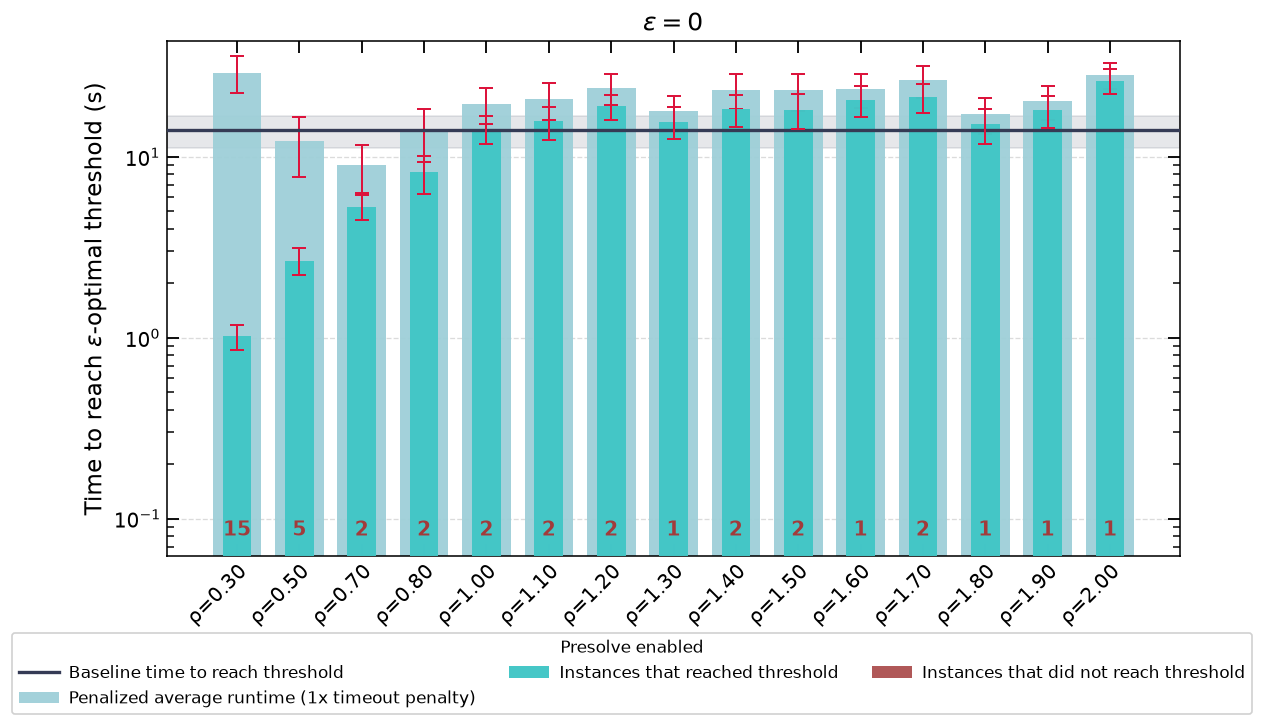

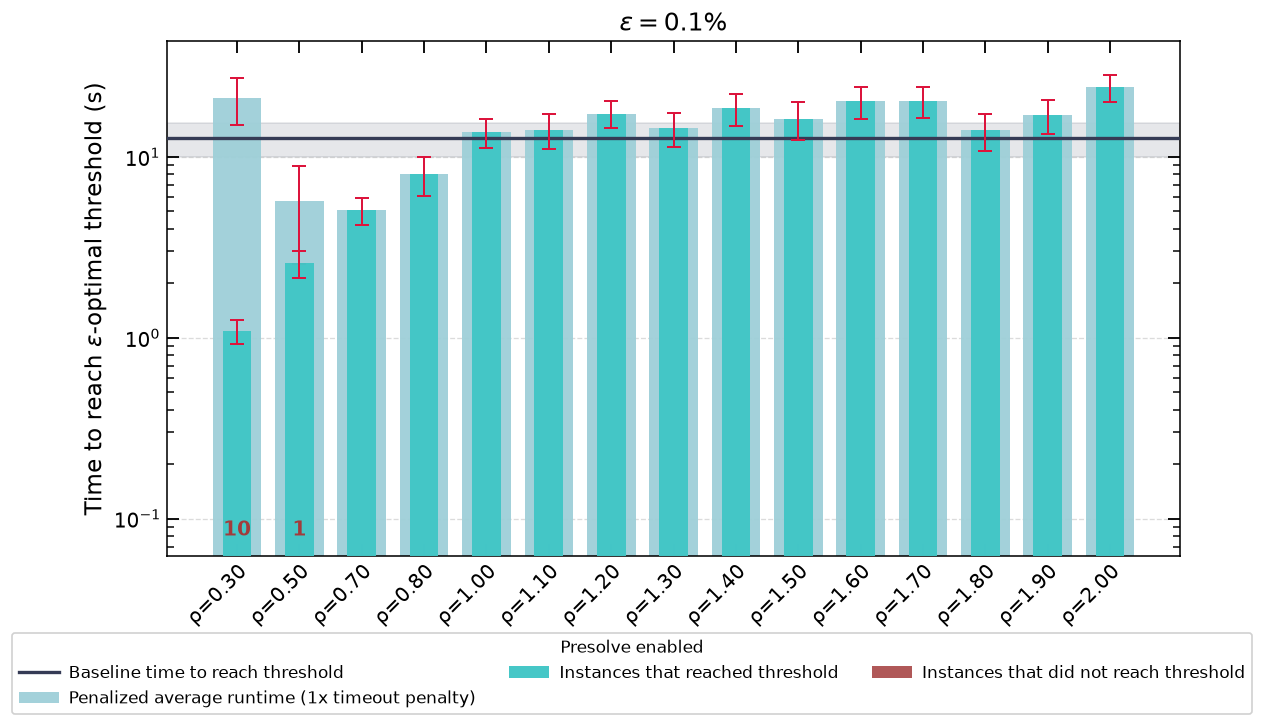

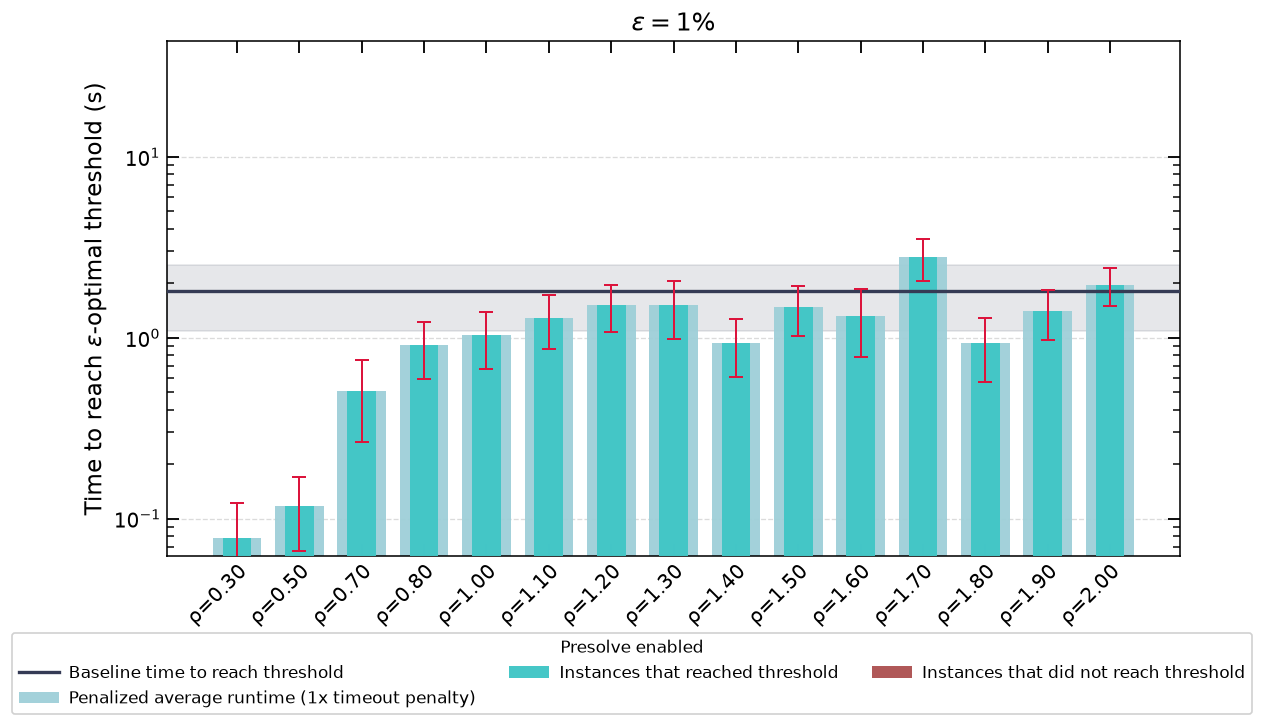

In [2]:
quantum_summary_df = load_summary_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_traj_by_presolve = load_trajectory_data(
    n=N,
    family="quantum",
    layers=QUANTUM_LAYER,
    results_dir=RESULTS_DIR,
)
quantum_pre = prepare_penalty_metrics(quantum_summary_df)

plot_ratio_minus_one(quantum_pre, quantum_cfg)
plt.show()

quantum_hit_df = prepare_hit_time_metrics(
    quantum_summary_df,
    quantum_traj_by_presolve,
    quantum_cfg,
    THRESHOLDS_TO_PLOT,
    penalty_factor=PAR_FACTOR,
)
quantum_selected_hit_df = quantum_hit_df[quantum_hit_df["presolve"] == PRESOLVE].copy()
quantum_shared_y_limits = (
    compute_hit_time_plot_limits(
        quantum_selected_hit_df,
        presolve=PRESOLVE,
        thresholds=THRESHOLDS_TO_PLOT,
        penalty_filter=PENALTY_FILTER,
    )
    if LOG_TIME_AXIS
    else None
)

for threshold in THRESHOLDS_TO_PLOT:
    plot_hit_time_vs_penalty(
        quantum_selected_hit_df,
        quantum_cfg,
        presolve=PRESOLVE,
        thresholds=[threshold],
        penalty_filter=PENALTY_FILTER,
        y_log=LOG_TIME_AXIS,
        y_limits=quantum_shared_y_limits,
    )
    plt.show()


### PAR (Penalized Average Runtime) line view

Same underlying data as the bar charts above, but only ε=0 and ε=1%
(`LINE_EPS_THRESHOLDS`), redrawn as connected lines so the trend across ρ is
easier to follow, with presolve enabled (left) and disabled (right) side by
side on a shared, matched y-axis. For instances that never reach the
threshold within the recorded trajectory, the dashed **PAR** line substitutes
`own_runtime_sec + PAR_FACTOR × baseline_runtime_sec` in place of a hit-time
— a standard way to penalize non-convergence without just discarding the
instance. The dark-red numbers above the ε=0 markers show how many instances
(out of the total at that N) never converged, which is what's driving PAR
above the solid "reached" line at that point.


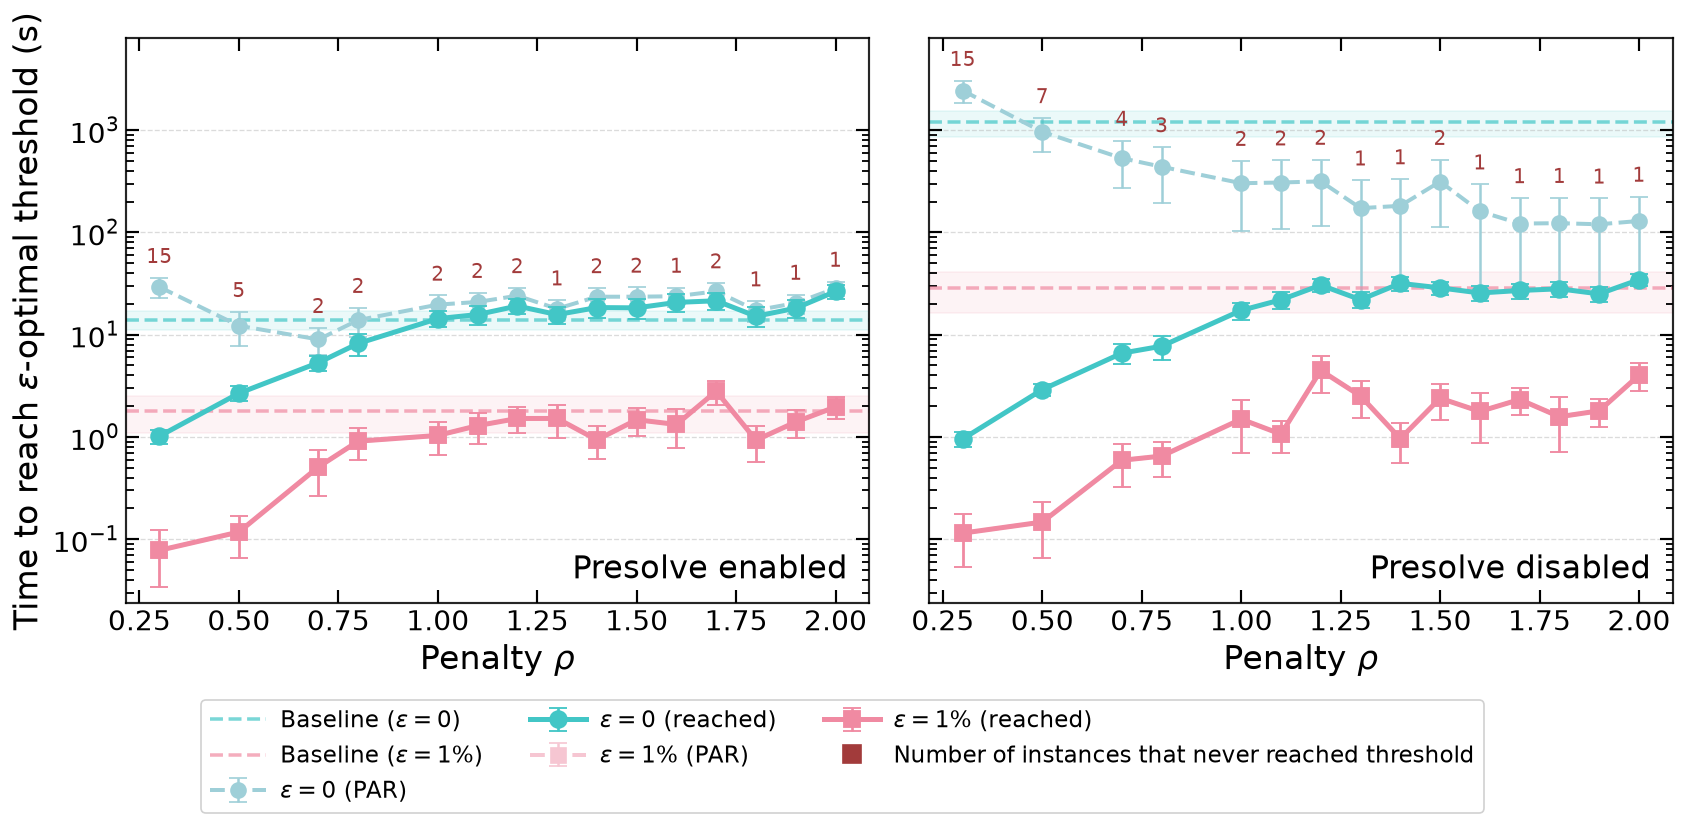

In [3]:
# Combined line-plot version of the bar charts above: both eps=0 and eps=1%
# on the same axes, presolve enabled (left) vs disabled (right) side by side.
fig_par_side = plot_hit_time_lines_side_by_side_presolve(
    quantum_hit_df,
    quantum_cfg,
    thresholds=LINE_EPS_THRESHOLDS,
    penalty_filter=PENALTY_FILTER,
    y_log=LOG_TIME_AXIS,
)
plt.savefig(REPO_ROOT / "figures" / "Combined_PAR_N40_p1.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantum Single-Seed MIPSol Trajectory

Zooms into one specific seed (`TRAJ_SEED`) and shows how Gurobi's incumbent
solution evolves during a *single* solve, one line per tested penalty
ρ (filtered to `TRAJ_PENALTY_FILTER`). The y-axis is the **original baseline
objective** evaluated at each improving incumbent, expressed as a ratio
relative to the true optimum — so you can watch individual solves converge (or
stall) in wall-clock time, rather than only seeing aggregated statistics
across seeds. Useful for sanity-checking that a ρ which looks bad in the
aggregate plots above isn't just one pathological seed, or vice versa.


Note on the log-scale y-axis: `Approx Ratio - 1` is exactly 0 at the moment
an incumbent reaches the baseline optimum, and a log axis cannot display 0 —
so each curve visually ends at its last *nonzero* gap. A line that stops
short of the bottom therefore means "converged to the optimum at that time",
not that the trajectory was truncated.


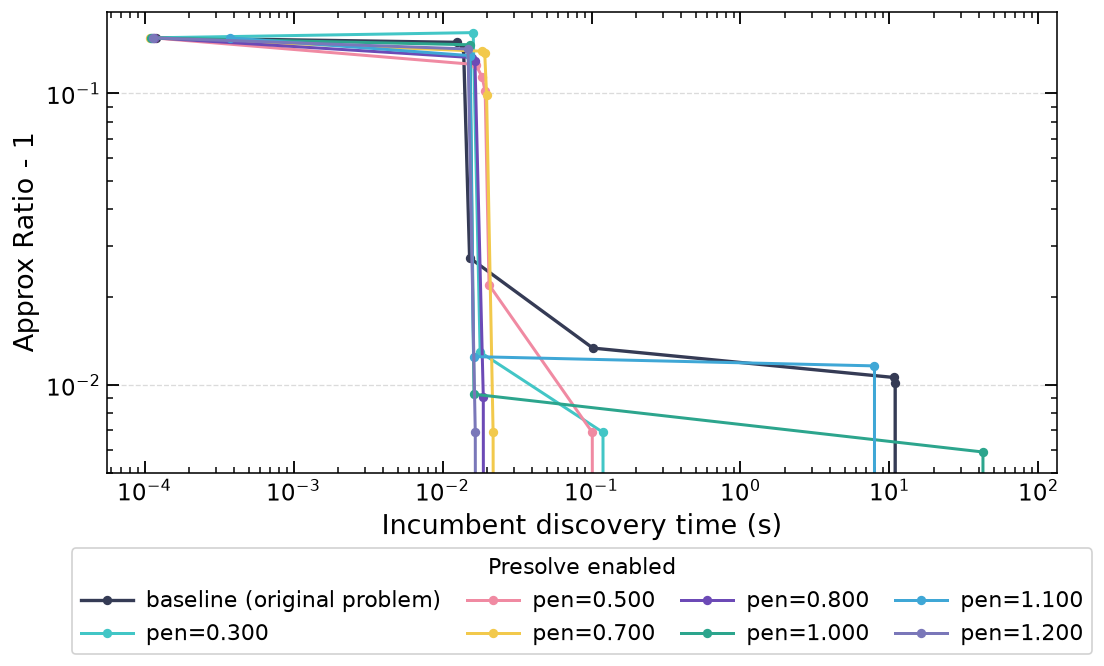

In [4]:
plot_mipsol_ratio_minus_one(
    traj_df=quantum_traj_by_presolve[PRESOLVE],
    cfg=quantum_cfg,
    presolve=PRESOLVE,
    mode="single",
    seed=TRAJ_SEED,
    penalty_filter=TRAJ_PENALTY_FILTER,
    value_col=MIPSOL_VALUE_COL,
)
plt.savefig(REPO_ROOT / "figures" / "Trajectory_N40_p1.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantum Scaling Across Problem Sizes

The core scaling result: for each QAOA depth p (and the classical baseline),
each instance uses its own retrospective best ρ, the **oracle strategy**.
This is an upper bound on what's achievable, since it requires already
knowing which ρ works best for that specific instance before solving it, not
one a practitioner could commit to in advance (a single global ρ, plus a
more realistic cross-validated estimate, is compared in the next section).
Presolve enabled (left) and disabled (right) are shown side by side on a
matched y-axis. Fitted lines are `O(base^n)` power laws; **N=8 is excluded**
(anomalously slow at this size, see the code comment above).

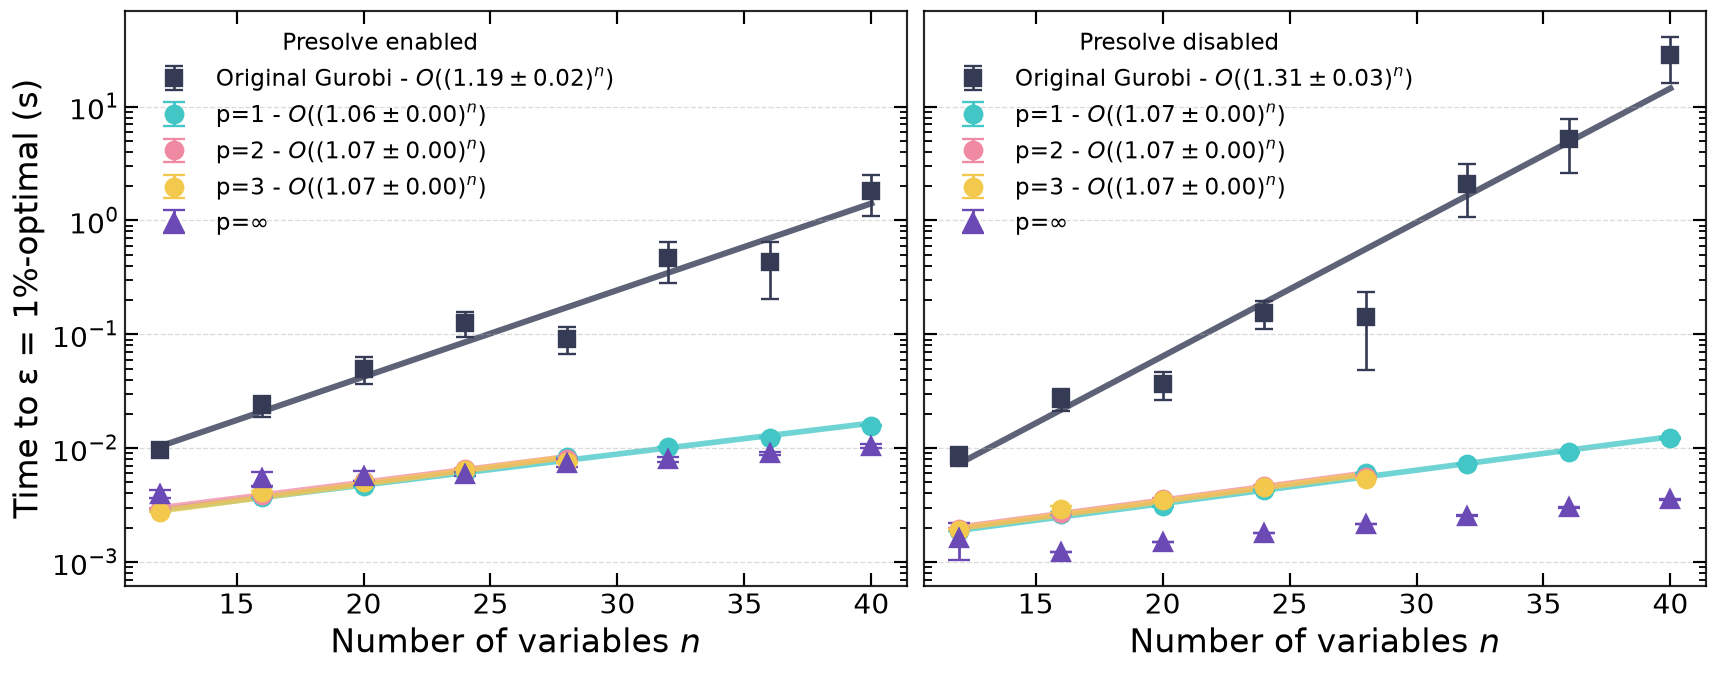

In [5]:
# Side-by-side quantum scaling: presolve enabled (left) vs disabled (right).
# Self-contained (loads its own on/off data) so it doesn't depend on the
# global PRESOLVE toggle.
quantum_side_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_side_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_side_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_side_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=DATA_ROOT,
    )
    quantum_side_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=DATA_ROOT,
    )
    quantum_side_on_df = pd.concat([quantum_side_on_df, quantum_side_on_inf_df], ignore_index=True)
    quantum_side_off_df = pd.concat([quantum_side_off_df, quantum_side_off_inf_df], ignore_index=True)

quantum_side_combined_df = pd.concat([quantum_side_on_df, quantum_side_off_df], ignore_index=True)
quantum_side_combined_traj_df = pd.concat([quantum_side_on_traj_df, quantum_side_off_traj_df], ignore_index=True)

fig_side = plot_layer_comparison_side_by_side_presolve(
    summary_df=quantum_side_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_side_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
    penalty_strategy="oracle",
)
plt.savefig(REPO_ROOT / "figures" / "Combined_Scaling_Plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantum Scaling — Penalty Strategies (Global ρ vs Cross-Validated)

Same scaling metric as above, but comparing two ways of choosing ρ *in
advance*, without oracle hindsight:

- **Global ρ** (left column): one ρ per depth, chosen once across every N
  and applied to every instance at every N, the value that minimizes the
  mean time-to-ε=1%-optimal averaged across N.
- **Cross-validated ρ** (right column): each seed's ρ is chosen from
  whichever value performed best on the *other* seeds at the same N (leave-
  one-out), a more realistic, still-legitimate estimate of what a real
  calibration procedure could achieve.

Rows are presolve enabled (top) / disabled (bottom); within each row, both
columns share one y-axis (Global ρ and Cross-validated are directly
comparable at a glance), while the two rows are independent of each other.
The oracle upper bound from the previous section isn't repeated here, this
grid is specifically about two strategies a practitioner could actually
deploy.

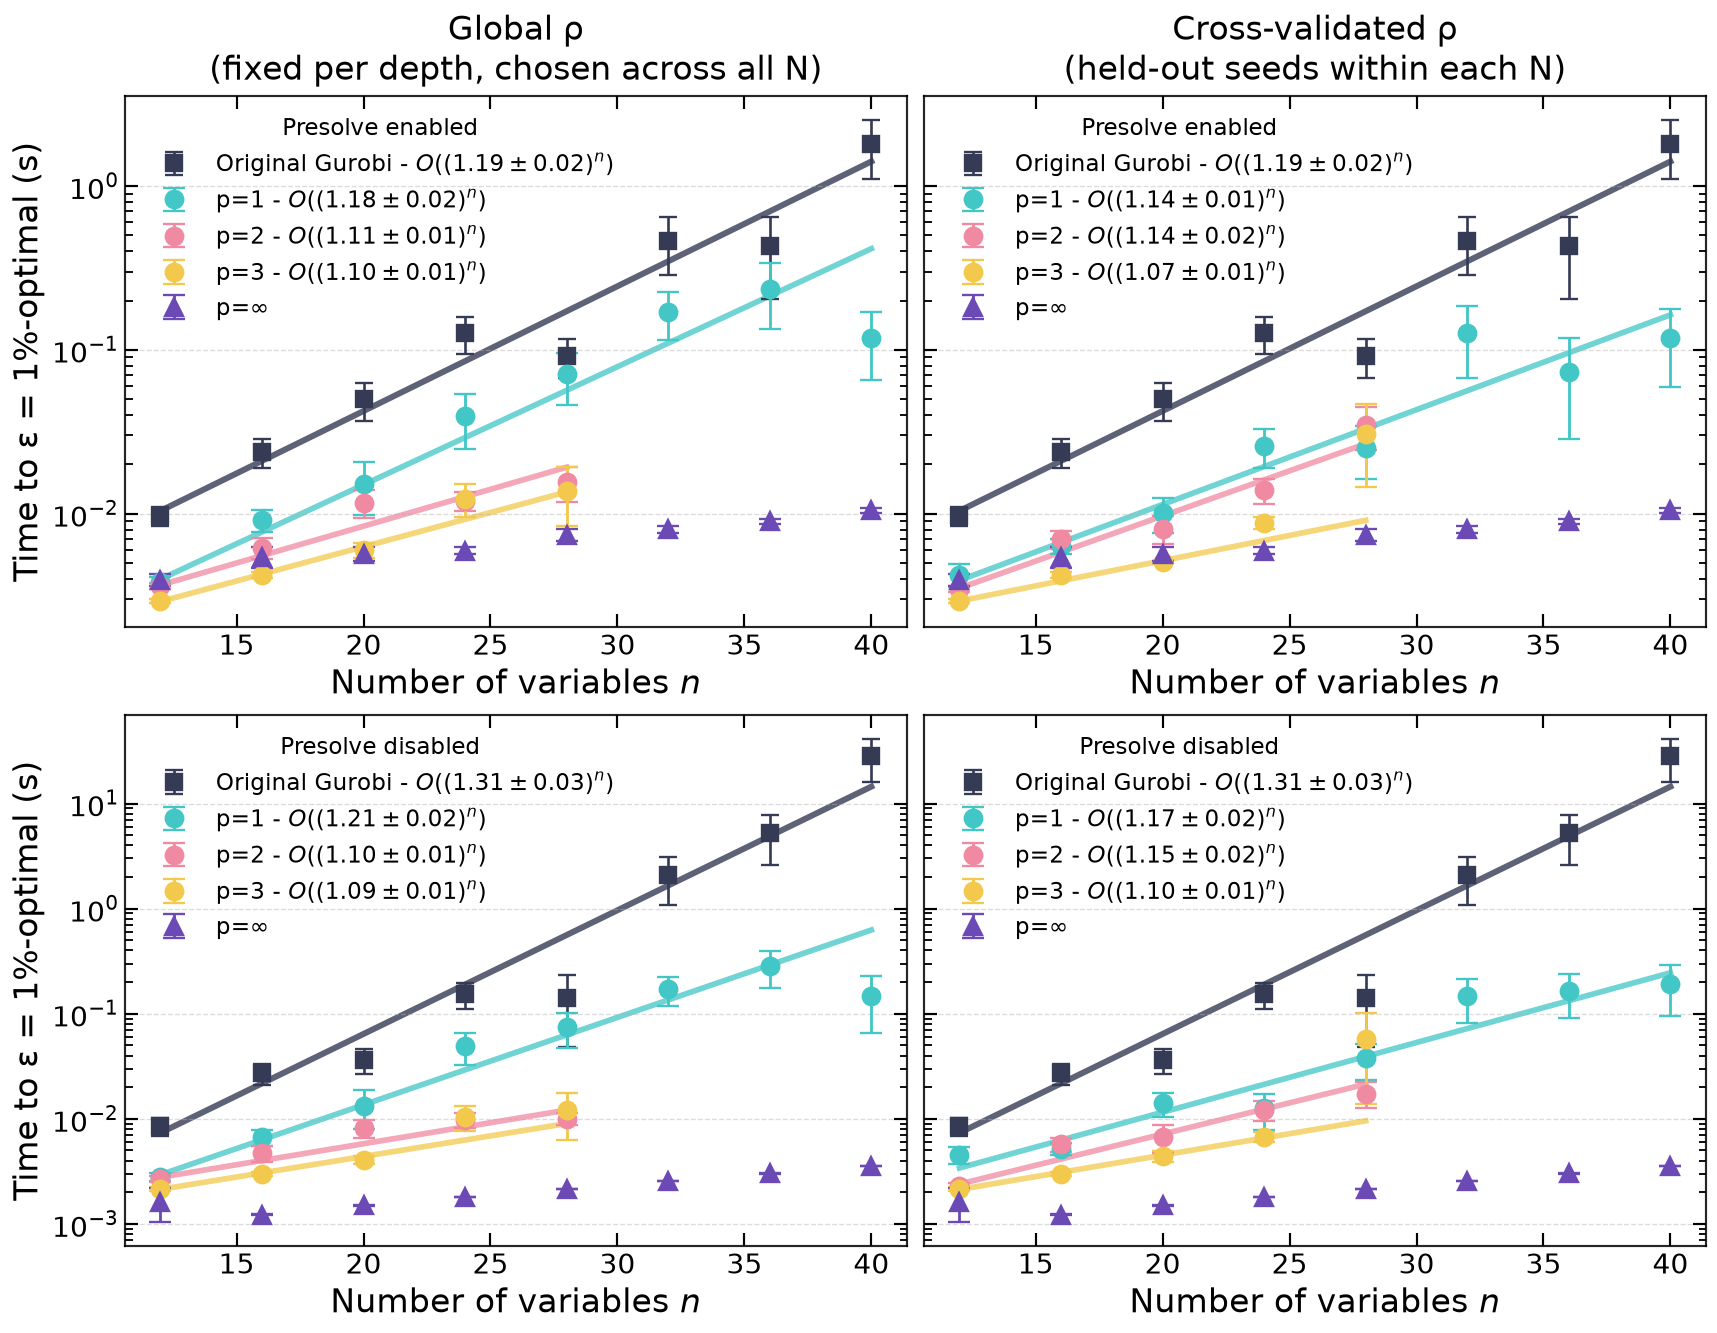

In [6]:
# Combined scaling grid: rows = presolve on/off, cols = global-fixed/cross-validated
# strategy, eps=1% only. Self-contained (loads its own on/off data) so it
# doesn't depend on whatever the global PRESOLVE toggle happens to be set to.
quantum_grid_on_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_on_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_ON,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=True,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_df = load_family_comparison_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_LAYERS,
    presolve=False,
    results_dir=RESULTS_DIR,
)
quantum_grid_off_traj_df = load_family_comparison_trajectory_data(
    problem_sizes=QUANTUM_SCALING_SIZES_OFF,
    family="quantum",
    param_values=QUANTUM_COMPARE_PARAMS,
    presolve=False,
    results_dir=RESULTS_DIR,
)

if INCLUDE_P_INF:
    quantum_grid_on_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_ON,
        presolve=True,
        results_dir=RESULTS_DIR,
        data_root=DATA_ROOT,
    )
    quantum_grid_off_inf_df = load_quantum_infinite_depth_comparison_data(
        problem_sizes=QUANTUM_SCALING_SIZES_OFF,
        presolve=False,
        results_dir=RESULTS_DIR,
        data_root=DATA_ROOT,
    )
    quantum_grid_on_df = pd.concat([quantum_grid_on_df, quantum_grid_on_inf_df], ignore_index=True)
    quantum_grid_off_df = pd.concat([quantum_grid_off_df, quantum_grid_off_inf_df], ignore_index=True)

quantum_grid_combined_df = pd.concat([quantum_grid_on_df, quantum_grid_off_df], ignore_index=True)
quantum_grid_combined_traj_df = pd.concat([quantum_grid_on_traj_df, quantum_grid_off_traj_df], ignore_index=True)

fig_grid = plot_layer_comparison_grid_by_presolve(
    summary_df=quantum_grid_combined_df,
    layers_list=QUANTUM_COMPARE_PARAMS,
    traj_df=quantum_grid_combined_traj_df,
    eps_threshold=EPS_THRESHOLD,
    y_log=True,
)
plt.savefig(REPO_ROOT / "figures" / "Combined_Scaling_Strategies.png", dpi=150, bbox_inches="tight")
plt.show()

## Performance Distribution

For each QAOA depth p and problem size N, this uses the oracle strategy
(each instance's own retrospective best ρ), matching the paper's Figure 6
and the same upper-bound strategy as the scaling plot above. Unlike the
scaling plots, which report *time*, this plot reports final solution
*quality*: for each instance at its own oracle ρ, `performance % = 100 ×
(1 − (final_baseline_obj − true_opt) / |true_opt|)`, where 100% means the
preconditioned solve matched the classical optimum exactly. The top strip
shows the fraction of instances landing at exactly 100% per N (headline
number above each column); the log-scale main panel shows the density-colored
spread of whatever didn't quite reach 100%, with a black bar for the mean. A
depth that looks fast can still show a wide quality spread here, speed and
exact-recovery reliability are different things, and this plot is what tells
you about the latter.

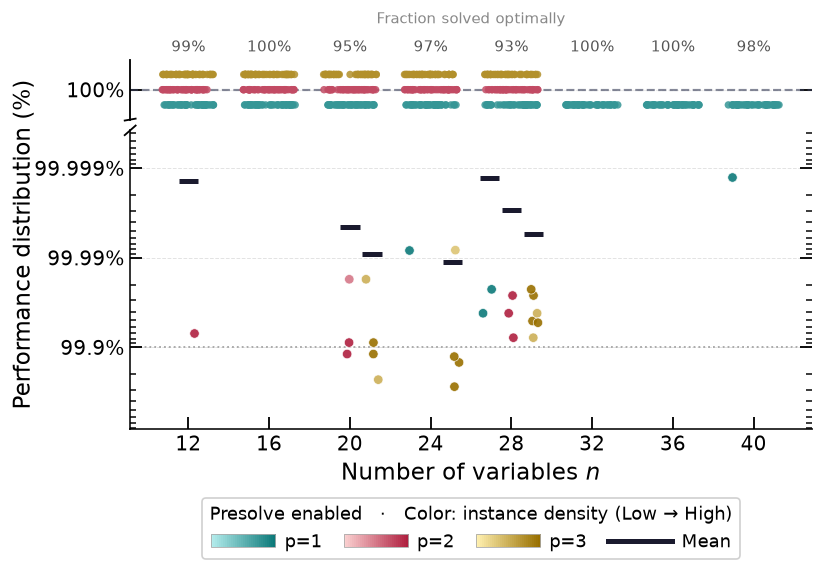

In [7]:
# Build per-p DataFrames for the performance distribution plot
perf_dfs = {}
for _p in QUANTUM_LAYERS:
    _frames = []
    for _n in QUANTUM_SCALING_SIZES:
        _fname = RESULTS_DIR / f"N={_n}_layers={_p}_presolve_{'on' if PRESOLVE else 'off'}.csv"
        try:
            _frames.append(pd.read_csv(_fname))
        except FileNotFoundError:
            pass
    if _frames:
        perf_dfs[f"p={_p}"] = pd.concat(_frames, ignore_index=True)

# Matches the paper's Figure 6: oracle strategy, the same per-instance
# upper-bound rho selection as the main scaling plot above.
fig_perf = plot_performance_distribution(perf_dfs, presolve=PRESOLVE, strategy="oracle")
plt.savefig(REPO_ROOT / "figures" / "performance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Supplementary: Global-ρ Performance Distribution

The performance-distribution plot above uses the oracle strategy (each
instance's own retrospective best ρ), matching the paper's Figure 6. The
cell below re-renders the same plot under the **`"fixed"`** strategy
instead, reusing the scaling grid's own Global-ρ selection (one ρ per depth,
chosen once across every N) rather than a per-instance upper bound. This is
a more realistic, deployable comparison, not something the paper itself
reports, and no other cell in this notebook depends on it. It reuses
`perf_dfs`, already loaded above.

Global ρ per depth (from the scaling grid): {'p=1': 0.5, 'p=2': 0.6, 'p=3': 0.3}


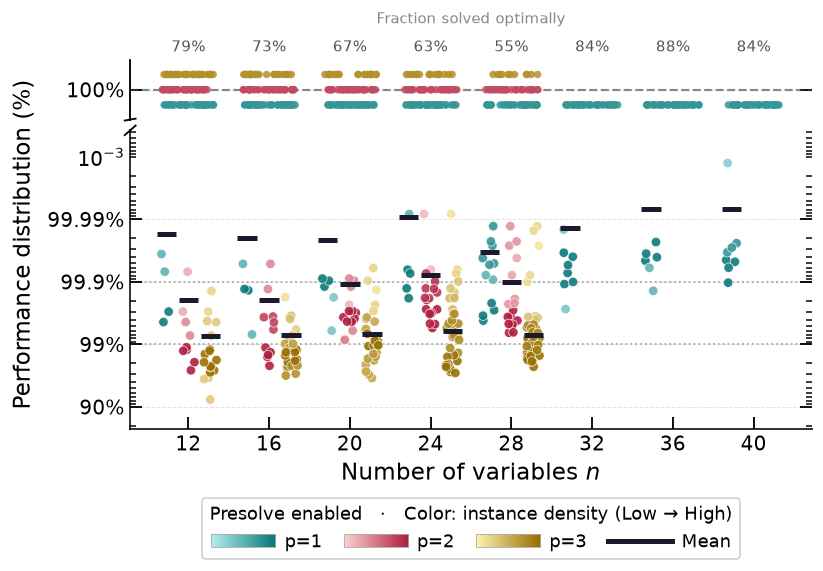

In [8]:
# Global-rho (fixed) version of the performance-distribution plot: reuses
# perf_dfs from above and the grid's own rho selection, so this reports
# quality under the SAME rho the scaling grid used for its Global-rho
# column, rather than a per-instance oracle pick.
_rho_by_depth = compute_fixed_rho_by_depth(
    summary_df=quantum_grid_combined_df,
    traj_df=quantum_grid_combined_traj_df,
    layers_list=QUANTUM_LAYERS,
    presolve=PRESOLVE,
    eps_threshold=EPS_THRESHOLD,
)
fixed_rho_by_label = {f"p={int(_p)}": _rho for _p, _rho in _rho_by_depth.items()}
print(f"Global ρ per depth (from the scaling grid): {fixed_rho_by_label}")

fig_perf_fixed = plot_performance_distribution(
    perf_dfs, presolve=PRESOLVE, fixed_rho_by_label=fixed_rho_by_label,
)
plt.savefig(REPO_ROOT / "figures" / "performance_distribution_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

### Why does deeper QAOA widen the performance-distribution spread?

The performance-distribution plot above and the scaling plot earlier in this
notebook both use oracle-selected ρ (each instance's own best), so the
widest quality spread at p=3 isn't a symptom of a bad ρ choice or a "ran out
of time" effect, every Gurobi solve here terminates at a certified optimum.
We looked at the correlation matrix itself for a possible association: for
each instance, at its own oracle ρ, compute the Pearson correlation between
the preconditioned quadratic weights and the true optimal solution's own
pairwise sign pattern (`z*_i * z*_j`), then negate it. The raw Pearson
correlation is negative when the objective favors `z*` as its minimizer (a
minimization objective wants each term `W_ij * z*_i * z*_j` negative, which
means `W_ij` and `z*_i * z*_j` need opposite signs), so negating it gives a
heuristic **alignment score** where higher means more aligned with the true
optimum, matching normal intuition instead of the raw, inverted Pearson
sign. It's a descriptive linear statistic, not proof that the objective
favors `z*`, and we have not tested it directly against hit-time or the
performance-distribution spread, so what follows is an association we
noticed, not an explanation we've established.

Mean alignment is lowest at p=1 at every size tested, and generally higher
at p=2 and p=3, though not monotonically, n=12 is an exception where p=2
(0.53) is slightly higher than p=3 (0.48). The standard deviation of
alignment does widen cleanly with depth at every single size, roughly
doubling from p=1 to p=3 throughout, and the single worst-aligned instance
at each size gets measurably weaker too. So p=3 tends to be both the most
aligned on average and the most variable, an association worth reporting,
not a demonstrated cause of the quality spread above.

This shows *what* the correlation matrices look like, not *why* the
variance grows with depth specifically, or whether alignment actually
drives the quality spread rather than just moving alongside it. That would
need a direct alignment-vs-performance test, which this notebook doesn't
attempt.

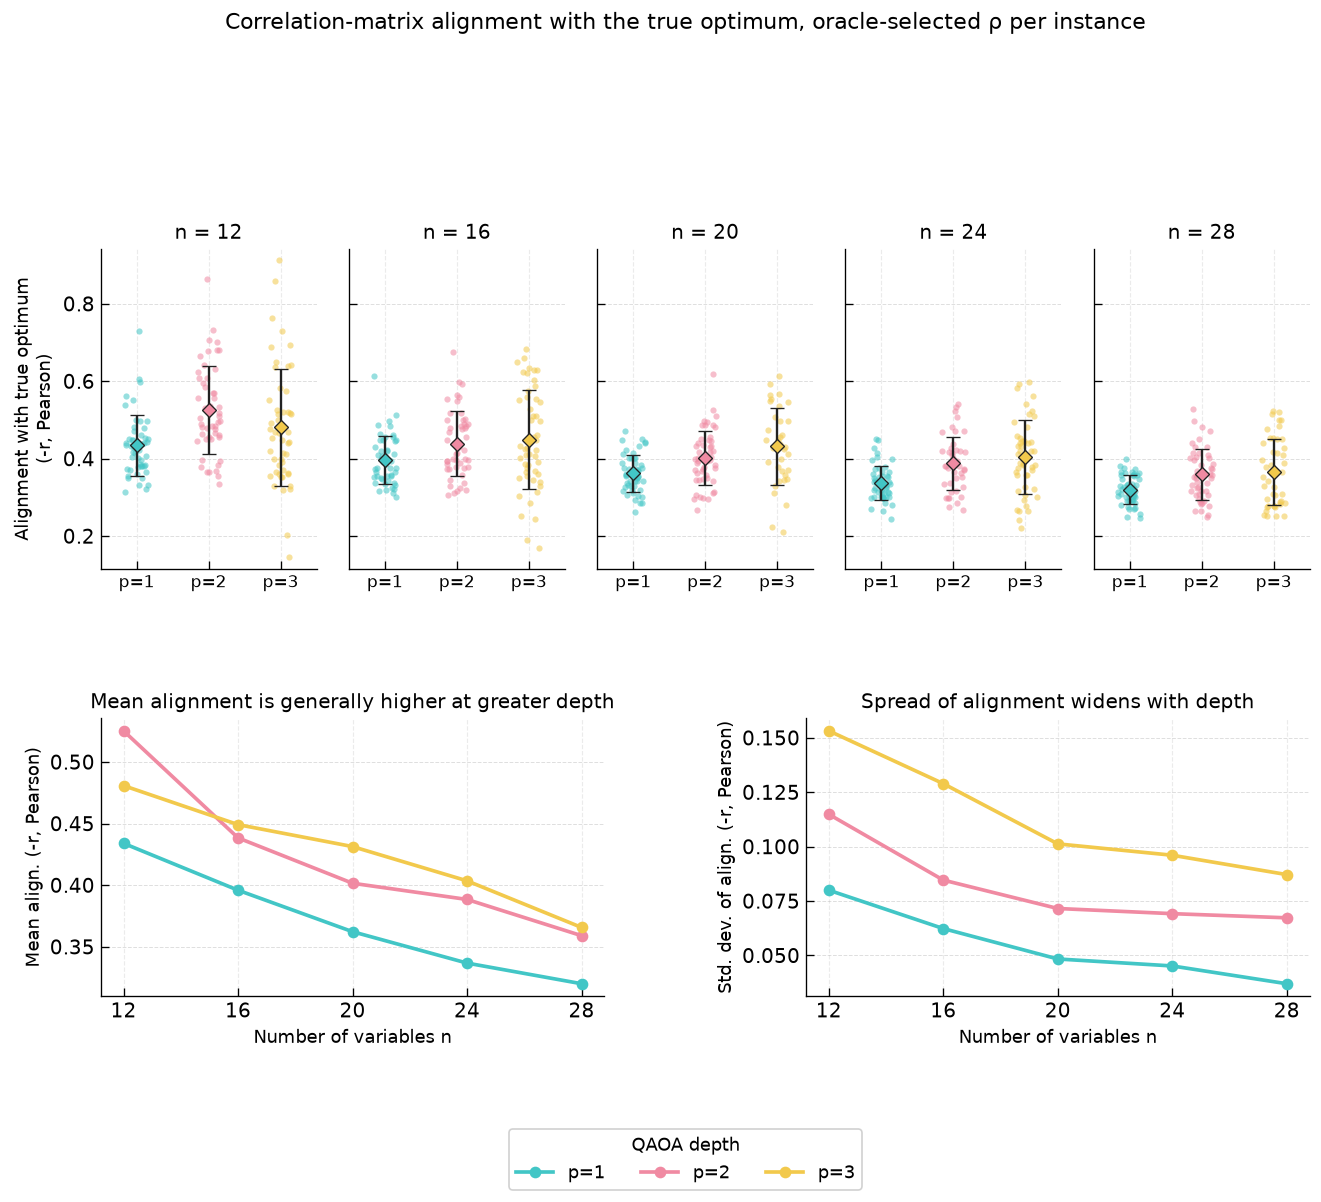

In [9]:
# p=2/p=3 correlation matrices only exist through N=28 (see scaling-plot
# markdown above), so that's the range this check can cover.
ALIGN_SIZES = [12, 16, 20, 24, 28]

align_records = []
for _n in ALIGN_SIZES:
    for _p in QUANTUM_LAYERS:
        _fname = RESULTS_DIR / f"N={_n}_layers={_p}_presolve_{'on' if PRESOLVE else 'off'}.csv"
        if not _fname.exists():
            continue
        _df = pd.read_csv(_fname)
        _df = _df[_df["presolve"] == PRESOLVE]
        _bl = _df[_df["name"] == "baseline"][["seed", "objective_baseline", "x_bits"]].rename(
            columns={"objective_baseline": "bl_opt"}
        )
        _pre = _df[_df["name"] != "baseline"].merge(_bl[["seed", "bl_opt"]], on="seed", how="left")
        _pre = _pre[_pre["bl_opt"].notna() & (_pre["bl_opt"] != 0)].copy()
        _pre["perf"] = 100.0 * (1.0 - (_pre["objective_baseline"] - _pre["bl_opt"]) / _pre["bl_opt"].abs())
        _pre["_gap"] = 100.0 - _pre["perf"]
        _oracle = qutils._apply_penalty_strategy(_pre, "_gap", "oracle")

        for _, _row in _oracle.iterrows():
            _seed = int(_row["seed"])
            _pen = round(float(_row["penalty"]), 3)
            _x_bits_row = _bl[_bl["seed"] == _seed]["x_bits"].iloc[0]
            _x_bits = [int(c) for c in str(_x_bits_row).zfill(_n)]
            _z_star = np.array(z_from_x(_x_bits))
            _fp = (
                DATA_ROOT / f"N={_n}" / f"seed={_seed}" / f"n_qaoa_layers={_p}"
                / f"preconditioned_problem_pen={_pen:.3f}.dat"
            )
            if not _fp.exists():
                continue
            _inst = read_dat(_fp)
            _w_vals = []
            _ideal_vals = []
            for (_i, _j), _w in _inst.quadratic.items():
                _w_vals.append(_w)
                _ideal_vals.append(_z_star[_i] * _z_star[_j])
            # Raw Pearson r is *negative* when W_ij favors z* as the minimizer
            # (minimization wants W_ij * z*_i * z*_j < 0 per term, i.e. W_ij
            # and z*_i*z*_j opposite in sign). Negate so higher = more
            # aligned, matching normal intuition instead of the inverted
            # raw sign.
            _align_r = -float(np.corrcoef(_w_vals, _ideal_vals)[0, 1])
            align_records.append({"n": _n, "p": _p, "seed": _seed, "align_r": _align_r})

align_df = pd.DataFrame(align_records)

_COLORS = {1: "#42C6C6", 2: "#F08AA2", 3: "#F2C94C"}
_ps = [1, 2, 3]
_rng = np.random.default_rng(0)
_y_min, _y_max = align_df["align_r"].min() - 0.03, align_df["align_r"].max() + 0.03

fig_align = plt.figure(figsize=(13, 9))
_gs = fig_align.add_gridspec(2, 1, height_ratios=[1.15, 1], hspace=0.5)
_gs_top = _gs[0].subgridspec(1, len(ALIGN_SIZES), wspace=0.15)
_gs_bottom = _gs[1].subgridspec(1, 2, wspace=0.4)

for _ci, _n in enumerate(ALIGN_SIZES):
    _ax = fig_align.add_subplot(_gs_top[0, _ci])
    for _p in _ps:
        _vals = align_df[(align_df["n"] == _n) & (align_df["p"] == _p)]["align_r"].to_numpy()
        if len(_vals) == 0:
            continue
        _jitter = _rng.uniform(-0.16, 0.16, size=len(_vals))
        _ax.scatter(_p + _jitter, _vals, s=14, alpha=0.55, color=_COLORS[_p], linewidths=0, zorder=2)
        _mean, _std = _vals.mean(), _vals.std()
        _ax.errorbar(
            [_p], [_mean], yerr=[_std], fmt="D", color=_COLORS[_p],
            markersize=6, markeredgecolor="#222222", markeredgewidth=0.8,
            ecolor="#222222", elinewidth=1.4, capsize=4, capthick=1.4, zorder=3,
        )
    _ax.set_xlim(0.5, 3.5)
    _ax.set_ylim(_y_min, _y_max)
    _ax.set_xticks(_ps)
    _ax.set_xticklabels([f"p={_p}" for _p in _ps], fontsize=10)
    _ax.set_title(f"n = {_n}", fontsize=12)
    _ax.tick_params(axis="both", direction="in", length=5)
    _ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)
    if _ci == 0:
        _ax.set_ylabel("Alignment with true optimum\n(-r, Pearson)", fontsize=11)
    else:
        _ax.tick_params(axis="y", labelleft=False)
    for _side in ["top", "right"]:
        _ax.spines[_side].set_visible(False)

_ax_mean = fig_align.add_subplot(_gs_bottom[0, 0])
_ax_std = fig_align.add_subplot(_gs_bottom[0, 1])

_summary = align_df.groupby(["n", "p"])["align_r"].agg(["mean", "std"]).reset_index()
for _p in _ps:
    _sub = _summary[_summary["p"] == _p].sort_values("n")
    _ax_mean.plot(_sub["n"], _sub["mean"], marker="o", markersize=6, linewidth=2.2, color=_COLORS[_p], label=f"p={_p}")
    _ax_std.plot(_sub["n"], _sub["std"], marker="o", markersize=6, linewidth=2.2, color=_COLORS[_p], label=f"p={_p}")

for _ax, _title, _ylab in [
    (_ax_mean, "Mean alignment is generally higher at greater depth", "Mean align. (-r, Pearson)"),
    (_ax_std, "Spread of alignment widens with depth", "Std. dev. of align. (-r, Pearson)"),
]:
    _ax.set_xlabel("Number of variables n", fontsize=11)
    _ax.set_ylabel(_ylab, fontsize=11)
    _ax.set_title(_title, fontsize=12)
    _ax.tick_params(axis="both", direction="in", length=5)
    _ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)
    _ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
    for _side in ["top", "right"]:
        _ax.spines[_side].set_visible(False)

fig_align.suptitle(
    "Correlation-matrix alignment with the true optimum, oracle-selected ρ per instance",
    fontsize=13, y=1.02,
)

# Grow the figure to make room for the legend below the x-axis labels,
# without shrinking the axes already laid out above (same technique used
# for the PAR bar chart's legend earlier in this notebook).
_top_in = fig_align.subplotpars.top * fig_align.get_figheight()
_bottom_in = fig_align.subplotpars.bottom * fig_align.get_figheight()
_extra_height_in = 0.7
_new_height = fig_align.get_figheight() + _extra_height_in
fig_align.set_size_inches(fig_align.get_figwidth(), _new_height, forward=True)
fig_align.subplots_adjust(
    top=1 - (fig_align.get_figheight() - _top_in) / fig_align.get_figheight(),
    bottom=(_bottom_in + _extra_height_in) / fig_align.get_figheight(),
)

_handles, _labels = _ax_mean.get_legend_handles_labels()
fig_align.legend(
    _handles, _labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.0),
    frameon=True, framealpha=0.9, edgecolor="#CCCCCC", fontsize=11,
    title="QAOA depth", title_fontsize=11,
)

fig_align.savefig(REPO_ROOT / "figures" / "Correlation_Alignment_By_Depth.png", dpi=150, bbox_inches="tight")
plt.show()